In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from pathlib import Path
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RAW_DIR = Path("/Users/tonytony/Final Project/Data/Raw")

GDP_PATH = RAW_DIR / "gdp.csv"
LIFE_PATH = RAW_DIR / "life_expectancy.csv"
POP_PATH = RAW_DIR / "population.csv"
INFLATION_PATH = RAW_DIR / "inflation.csv"
UNEMPLOYMENT_PATH = RAW_DIR / "unemployment.csv"
META_PATH = RAW_DIR / "world_bank_country_metadata.csv"

internet_candidates = sorted(RAW_DIR.glob("*Internet*.csv"))
if len(internet_candidates) == 0:
    raise FileNotFoundError("Internet dataset not found in Data/Raw")
INTERNET_PATH = internet_candidates[0]

print("GDP:", GDP_PATH)
print("Life:", LIFE_PATH)
print("Population:", POP_PATH)
print("Inflation:", INFLATION_PATH)
print("Unemployment:", UNEMPLOYMENT_PATH)
print("Internet:", INTERNET_PATH)
print("Metadata:", META_PATH)


GDP: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Life: /Users/tonytony/Final Project/Data/Raw/life_expectancy.csv
Population: /Users/tonytony/Final Project/Data/Raw/population.csv
Inflation: /Users/tonytony/Final Project/Data/Raw/inflation.csv
Unemployment: /Users/tonytony/Final Project/Data/Raw/unemployment.csv
Internet: /Users/tonytony/Final Project/Data/Raw/individuals_using_ the_Internet.csv
Metadata: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv


In [2]:
meta_df = pd.read_csv(META_PATH)

region_map = meta_df[[
    "Country Code",
    "World Bank Region"
]].copy().rename(columns={
    "Country Code": "country_code",
    "World Bank Region": "wb_region"
})

region_map["country_type"] = np.where(
    region_map["wb_region"].astype(str).str.strip().eq("Aggregates"),
    "Aggregate",
    "Country/Territory"
)

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    year_cols = [col for col in df.columns if str(col).isdigit()]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    return df

def to_long(df, value_name):
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name="year",
        value_name=value_name
    ).rename(columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    })

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("int64")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

def add_region_info(long_df):
    merged = long_df.merge(region_map, on="country_code", how="left")
    merged = merged[merged["country_type"] == "Country/Territory"].copy()
    return merged

print("Helpers ready")
region_map.head()


Helpers ready


,country_code,wb_region,country_type
0,ABW,Latin America & Caribbean,Country/Territory
1,AFE,Aggregates,Aggregate
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory
3,AFR,Aggregates,Aggregate
4,AFW,Aggregates,Aggregate


In [3]:
gdp_long = add_region_info(to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"))
life_long = add_region_info(to_long(load_wdi(LIFE_PATH), "life_expectancy_years"))
pop_long = add_region_info(to_long(load_wdi(POP_PATH), "population_total"))
inflation_long = add_region_info(to_long(load_wdi(INFLATION_PATH), "inflation_pct"))
unemployment_long = add_region_info(to_long(load_wdi(UNEMPLOYMENT_PATH), "unemployment_pct"))
internet_long = add_region_info(to_long(load_wdi(INTERNET_PATH), "internet_users_pct"))

gdp_long = gdp_long[(gdp_long["gdp_per_capita_usd"].notna()) & (gdp_long["gdp_per_capita_usd"] > 0)].copy()
life_long = life_long[life_long["life_expectancy_years"].notna()].copy()
pop_long = pop_long[(pop_long["population_total"].notna()) & (pop_long["population_total"] > 0)].copy()
inflation_long = inflation_long[inflation_long["inflation_pct"].notna()].copy()
unemployment_long = unemployment_long[unemployment_long["unemployment_pct"].notna()].copy()
internet_long = internet_long[internet_long["internet_users_pct"].notna()].copy()

print("GDP latest year:", int(gdp_long["year"].max()))
print("Life latest year:", int(life_long["year"].max()))
print("Population latest year:", int(pop_long["year"].max()))
print("Inflation latest year:", int(inflation_long["year"].max()))
print("Unemployment latest year:", int(unemployment_long["year"].max()))
print("Internet latest year:", int(internet_long["year"].max()))


GDP latest year: 2024
Life latest year: 2023
Population latest year: 2024
Inflation latest year: 2024
Unemployment latest year: 2025
Internet latest year: 2025


In [4]:
panel_df = gdp_long[[
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd"
]].merge(
    life_long[["country_code", "year", "life_expectancy_years"]],
    on=["country_code", "year"],
    how="inner"
).merge(
    pop_long[["country_code", "year", "population_total"]],
    on=["country_code", "year"],
    how="inner"
).merge(
    inflation_long[["country_code", "year", "inflation_pct"]],
    on=["country_code", "year"],
    how="left"
).merge(
    unemployment_long[["country_code", "year", "unemployment_pct"]],
    on=["country_code", "year"],
    how="left"
).merge(
    internet_long[["country_code", "year", "internet_users_pct"]],
    on=["country_code", "year"],
    how="left"
)

panel_df["log_gdp_per_capita"] = np.log(panel_df["gdp_per_capita_usd"])
panel_df["log_population_total"] = np.log(panel_df["population_total"])
panel_df = panel_df.sort_values(["country_code", "year"]).copy()
panel_df["target_log_gdp_next_year"] = panel_df.groupby("country_code")["log_gdp_per_capita"].shift(-1)

# Clean extra drivers
panel_df["inflation_pct_clean"] = panel_df["inflation_pct"].copy()
infl_q01 = panel_df["inflation_pct_clean"].quantile(0.01)
infl_q99 = panel_df["inflation_pct_clean"].quantile(0.99)
panel_df["inflation_pct_clean"] = panel_df["inflation_pct_clean"].clip(lower=infl_q01, upper=infl_q99)

panel_df["unemployment_pct_clean"] = panel_df["unemployment_pct"].where(
    panel_df["unemployment_pct"].between(0, 100),
    np.nan
)

panel_df["internet_users_pct_clean"] = panel_df["internet_users_pct"].where(
    panel_df["internet_users_pct"].between(0, 100),
    np.nan
)

# Historical event dummies
panel_df["asian_financial_crisis_9798"] = panel_df["year"].isin([1997, 1998]).astype(int)
panel_df["global_financial_crisis_0809"] = panel_df["year"].isin([2008, 2009]).astype(int)
panel_df["covid_shock_2020"] = (panel_df["year"] == 2020).astype(int)
panel_df["covid_rebound_2021"] = (panel_df["year"] == 2021).astype(int)
panel_df["ukraine_energy_shock_2022_2024"] = panel_df["year"].between(2022, 2024).astype(int)

year_base = int(panel_df["year"].min())
panel_df["year_trend"] = panel_df["year"] - year_base

print("Panel shape:", panel_df.shape)
print("Countries:", panel_df["country_code"].nunique())
print("Year range:", int(panel_df["year"].min()), "-", int(panel_df["year"].max()))

panel_df.head()


Panel shape: (11373, 22)
Countries: 214
Year range: 1960 - 2023


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,inflation_pct,unemployment_pct,internet_users_pct,...,target_log_gdp_next_year,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,year_trend
3665,Aruba,ABW,Latin America & Caribbean,1986,6767.559229,71.831,59931.0,1.073966,NaN,NaN,...,9.017246,1.073966,NaN,NaN,0,0,0,0,0,26
3833,Aruba,ABW,Latin America & Caribbean,1987,8244.045660,72.448,59159.0,3.643045,NaN,NaN,...,9.215951,3.643045,NaN,NaN,0,0,0,0,0,27
4007,Aruba,ABW,Latin America & Caribbean,1988,10056.261393,72.519,59331.0,3.121868,NaN,NaN,...,9.350730,3.121868,NaN,NaN,0,0,0,0,0,28
4183,Aruba,ABW,Latin America & Caribbean,1989,11507.217151,72.531,60443.0,3.991628,NaN,NaN,...,9.408169,3.991628,NaN,NaN,0,0,0,0,0,29
4359,Aruba,ABW,Latin America & Caribbean,1990,12187.536361,72.546,62753.0,5.836688,NaN,0.0,...,9.490544,5.836688,NaN,0.0,0,0,0,0,0,30


In [5]:
model_cols = [
    "target_log_gdp_next_year",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "wb_region",
    "year",
    "year_trend"
]

model_df = panel_df[["country_name", "country_code"] + model_cols].dropna().copy()

for col in [
    "target_log_gdp_next_year",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "year_trend"
]:
    model_df[col] = model_df[col].astype(float)

for col in [
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "year"
]:
    model_df[col] = model_df[col].astype("int64")

model_df["wb_region"] = model_df["wb_region"].astype(str)

print("Model sample shape:", model_df.shape)
model_df.head()


Model sample shape: (4722, 16)


,country_name,country_code,target_log_gdp_next_year,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,wb_region,year,year_trend
7369,Afghanistan,AFG,5.613925,17.010281,58.247,12.686269,7.878,1.224148,0,0,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2005,45.0
7578,Afghanistan,AFG,5.930182,17.051208,58.553,6.784597,7.897,2.107124,0,0,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2006,46.0
7788,Afghanistan,AFG,5.944722,17.070134,58.956,8.680571,7.841,1.900000,0,0,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2007,47.0
7998,Afghanistan,AFG,6.113801,17.091999,59.708,26.418664,7.879,1.840000,0,1,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2008,48.0
8209,Afghanistan,AFG,6.329046,17.128463,60.248,-2.828535,7.808,3.550000,0,1,0,0,0,"Middle East, North Africa, Afghanistan & Pakistan",2009,49.0


In [6]:
formula_model_1 = """
target_log_gdp_next_year ~ log_population_total
+ life_expectancy_years
"""

formula_model_2 = """
target_log_gdp_next_year ~ log_population_total
+ life_expectancy_years
+ inflation_pct_clean
+ unemployment_pct_clean
+ internet_users_pct_clean
"""

# Note:
# For true future forecasting, year fixed effects C(year) are replaced by a numeric year trend.
formula_model_3 = """
target_log_gdp_next_year ~ log_population_total
+ life_expectancy_years
+ inflation_pct_clean
+ unemployment_pct_clean
+ internet_users_pct_clean
+ asian_financial_crisis_9798
+ global_financial_crisis_0809
+ covid_shock_2020
+ covid_rebound_2021
+ ukraine_energy_shock_2022_2024
+ C(wb_region)
+ year_trend
"""

model_1 = smf.ols(formula=formula_model_1, data=model_df).fit(cov_type="HC3")
model_2 = smf.ols(formula=formula_model_2, data=model_df).fit(cov_type="HC3")
model_3 = smf.ols(formula=formula_model_3, data=model_df).fit(cov_type="HC3")

model_summary = pd.DataFrame([
    {
        "Model": "Model 1 - Baseline",
        "R_squared": model_1.rsquared,
        "Adj_R_squared": model_1.rsquared_adj,
        "AIC": model_1.aic,
        "BIC": model_1.bic
    },
    {
        "Model": "Model 2 - Extended",
        "R_squared": model_2.rsquared,
        "Adj_R_squared": model_2.rsquared_adj,
        "AIC": model_2.aic,
        "BIC": model_2.bic
    },
    {
        "Model": "Model 3 - Full Forecasting Model",
        "R_squared": model_3.rsquared,
        "Adj_R_squared": model_3.rsquared_adj,
        "AIC": model_3.aic,
        "BIC": model_3.bic
    }
]).round(4)

model_summary


,Model,R_squared,Adj_R_squared,AIC,BIC
0,Model 1 - Baseline,0.6950,0.6948,11927.8938,11947.2738
1,Model 2 - Extended,0.7484,0.7481,11024.2695,11063.0294
2,Model 3 - Full Forecasting Model,0.7983,0.7976,10003.7829,10120.0627


In [7]:
forecast_model_plan = pd.DataFrame({
    "Variable": ["Population", "Life Expectancy", "Inflation", "Unemployment", "Internet Usage"],
    "Forecast Model": ["LogHolt", "Holt", "ARIMA(1,1,1)", "AutoReg(lags=3)", "Holt"],
    "Why": [
        "Population is smooth and long-trending, so log-scale Holt trend is stable.",
        "Life expectancy usually follows a smooth long-term trend.",
        "Inflation is more volatile and macro-sensitive, so ARIMA is appropriate.",
        "Unemployment often has autoregressive persistence.",
        "Internet usage tends to follow a long-run trend with saturation behavior."
    ]
})

forecast_model_plan


,Variable,Forecast Model,Why
0,Population,LogHolt,"Population is smooth and long-trending, so log..."
1,Life Expectancy,Holt,Life expectancy usually follows a smooth long-...
2,Inflation,"ARIMA(1,1,1)",Inflation is more volatile and macro-sensitive...
3,Unemployment,AutoReg(lags=3),Unemployment often has autoregressive persiste...
4,Internet Usage,Holt,Internet usage tends to follow a long-run tren...


In [8]:
def build_series(df, country_code, value_col):
    temp = (
        df[df["country_code"] == country_code][["year", value_col]]
        .dropna()
        .sort_values("year")
        .drop_duplicates(subset=["year"], keep="last")
    )
    return pd.Series(temp[value_col].values, index=temp["year"].astype(int).values, dtype=float)

def forecast_series_to_year(series, target_year, model_type):
    series = series.dropna().astype(float)
    series = series[~series.index.duplicated(keep="last")]
    series = series.sort_index()

    if len(series) < 5:
        model_type = "Naive"

    last_year = int(series.index.max())
    full_map = {int(y): float(v) for y, v in series.items()}

    if target_year <= last_year:
        return full_map

    horizon = target_year - last_year
    values = pd.Series(series.values, dtype=float)

    try:
        if model_type == "Naive":
            fc = np.repeat(values.iloc[-1], horizon)

        elif model_type == "AutoReg":
            lags = min(3, max(1, len(values) // 4))
            fit = AutoReg(values, lags=lags, old_names=False, trend="c").fit()
            fc = fit.predict(start=len(values), end=len(values) + horizon - 1)
            fc = np.asarray(fc, dtype=float)

        elif model_type == "ARIMA":
            fit = ARIMA(
                values,
                order=(1, 1, 1),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            fc = fit.forecast(steps=horizon)
            fc = np.asarray(fc, dtype=float)

        elif model_type == "Holt":
            fit = ExponentialSmoothing(
                values,
                trend="add",
                seasonal=None,
                damped_trend=False
            ).fit()
            fc = fit.forecast(horizon)
            fc = np.asarray(fc, dtype=float)

        elif model_type == "LogHolt":
            log_values = np.log(values)
            fit = ExponentialSmoothing(
                log_values,
                trend="add",
                seasonal=None,
                damped_trend=False
            ).fit()
            fc = fit.forecast(horizon)
            fc = np.exp(np.asarray(fc, dtype=float))

        else:
            raise ValueError(f"Unknown model type: {model_type}")

    except Exception:
        fc = np.repeat(values.iloc[-1], horizon)

    future_years = list(range(last_year + 1, target_year + 1))
    for y, v in zip(future_years, fc):
        full_map[int(y)] = float(v)

    return full_map

def make_event_dummy_row(feature_year):
    return {
        "asian_financial_crisis_9798": int(feature_year in [1997, 1998]),
        "global_financial_crisis_0809": int(feature_year in [2008, 2009]),
        "covid_shock_2020": int(feature_year == 2020),
        "covid_rebound_2021": int(feature_year == 2021),
        "ukraine_energy_shock_2022_2024": int(2022 <= feature_year <= 2024)
    }

print("Future forecasting helpers are ready")


Future forecasting helpers are ready


In [9]:
def build_future_feature_table(country_code, target_gdp_year):
    pop_series = build_series(pop_long, country_code, "population_total")
    life_series = build_series(life_long, country_code, "life_expectancy_years")
    infl_series = build_series(inflation_long, country_code, "inflation_pct")
    unemp_series = build_series(unemployment_long, country_code, "unemployment_pct")
    internet_series = build_series(internet_long, country_code, "internet_users_pct")

    country_info = (
        gdp_long[gdp_long["country_code"] == country_code][["country_name", "country_code", "wb_region"]]
        .drop_duplicates()
        .head(1)
    )

    if country_info.empty:
        raise ValueError(f"Country code {country_code} not found")

    country_name = country_info["country_name"].iloc[0]
    wb_region = country_info["wb_region"].iloc[0]

    last_years = {
        "population_total": int(pop_series.index.max()),
        "life_expectancy_years": int(life_series.index.max()),
        "inflation_pct": int(infl_series.index.max()),
        "unemployment_pct": int(unemp_series.index.max()),
        "internet_users_pct": int(internet_series.index.max())
    }

    latest_common_feature_year = min(last_years.values())

    if target_gdp_year <= latest_common_feature_year:
        raise ValueError(
            f"Target GDP year must be greater than {latest_common_feature_year} for true future forecasting."
        )

    target_feature_year = target_gdp_year - 1

    pop_map = forecast_series_to_year(pop_series, target_feature_year, "LogHolt")
    life_map = forecast_series_to_year(life_series, target_feature_year, "Holt")
    infl_map = forecast_series_to_year(infl_series, target_feature_year, "ARIMA")
    unemp_map = forecast_series_to_year(unemp_series, target_feature_year, "AutoReg")
    internet_map = forecast_series_to_year(internet_series, target_feature_year, "Holt")

    rows = []
    for feature_year in range(latest_common_feature_year, target_feature_year + 1):
        row = {
            "country_name": country_name,
            "country_code": country_code,
            "wb_region": wb_region,
            "year": int(feature_year),
            "predicted_gdp_year": int(feature_year + 1),
            "population_total": float(pop_map[feature_year]),
            "life_expectancy_years": float(life_map[feature_year]),
            "inflation_pct_clean": float(infl_map[feature_year]),
            "unemployment_pct_clean": float(unemp_map[feature_year]),
            "internet_users_pct_clean": float(internet_map[feature_year]),
        }

        row["log_population_total"] = np.log(row["population_total"])
        row["year_trend"] = int(feature_year - year_base)
        row.update(make_event_dummy_row(feature_year))

        rows.append(row)

    future_feature_df = pd.DataFrame(rows)
    return future_feature_df, latest_common_feature_year, last_years


In [11]:
country_code_input = "VNM"
target_gdp_year_input = 2040

future_feature_df, latest_common_feature_year, feature_last_years = build_future_feature_table(
    country_code=country_code_input,
    target_gdp_year=target_gdp_year_input
)

print("Country:", country_code_input)
print("Latest common feature year:", latest_common_feature_year)
print("Raw feature last years:", feature_last_years)

future_feature_df.head(20)


Country: VNM
Latest common feature year: 2023
Raw feature last years: {'population_total': 2024, 'life_expectancy_years': 2023, 'inflation_pct': 2024, 'unemployment_pct': 2025, 'internet_users_pct': 2024}


,country_name,country_code,wb_region,year,predicted_gdp_year,population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,log_population_total,year_trend,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024
0,Viet Nam,VNM,East Asia & Pacific,2023,2024,1.003522e+08,74.588000,3.252893,1.645000,78.080000,18.424196,63,0,0,0,0,1
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,1.009877e+08,74.878363,3.621093,1.602000,84.150000,18.430509,64,0,0,0,0,1
2,Viet Nam,VNM,East Asia & Pacific,2025,2026,1.016272e+08,75.141266,3.300482,1.523000,87.796247,18.436822,65,0,0,0,0,0
3,Viet Nam,VNM,East Asia & Pacific,2026,2027,1.022708e+08,75.404169,3.314974,1.622057,91.442494,18.443134,66,0,0,0,0,0
4,Viet Nam,VNM,East Asia & Pacific,2027,2028,1.029184e+08,75.667072,3.314319,1.670083,95.088741,18.449447,67,0,0,0,0,0
5,Viet Nam,VNM,East Asia & Pacific,2028,2029,1.035702e+08,75.929975,3.314349,1.719086,98.734988,18.455760,68,0,0,0,0,0
6,Viet Nam,VNM,East Asia & Pacific,2029,2030,1.042260e+08,76.192877,3.314347,1.749728,102.381235,18.462072,69,0,0,0,0,0
7,Viet Nam,VNM,East Asia & Pacific,2030,2031,1.048861e+08,76.455780,3.314347,1.772793,106.027482,18.468385,70,0,0,0,0,0
8,Viet Nam,VNM,East Asia & Pacific,2031,2032,1.055503e+08,76.718683,3.314347,1.788373,109.673729,18.474698,71,0,0,0,0,0
9,Viet Nam,VNM,East Asia & Pacific,2032,2033,1.062187e+08,76.981586,3.314347,1.799428,113.319976,18.481011,72,0,0,0,0,0


In [15]:
future_feature_df["predicted_gdp_model_1"] = np.exp(model_1.predict(future_feature_df))
future_feature_df["predicted_gdp_model_2"] = np.exp(model_2.predict(future_feature_df))
future_feature_df["predicted_gdp_model_3"] = np.exp(model_3.predict(future_feature_df))

gdp_forecast_path = future_feature_df[[
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "predicted_gdp_year",
    "predicted_gdp_model_1",
    "predicted_gdp_model_2",
    "predicted_gdp_model_3"
]].copy()

gdp_forecast_path.tail(20)


,country_name,country_code,wb_region,year,predicted_gdp_year,predicted_gdp_model_1,predicted_gdp_model_2,predicted_gdp_model_3
0,Viet Nam,VNM,East Asia & Pacific,2023,2024,7201.637283,11906.862062,8166.794714
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,7502.712848,13352.283454,9250.199145
2,Viet Nam,VNM,East Asia & Pacific,2025,2026,7785.794972,14465.100518,9856.681776
3,Viet Nam,VNM,East Asia & Pacific,2026,2027,8079.557963,15673.492437,10531.188117
4,Viet Nam,VNM,East Asia & Pacific,2027,2028,8384.404820,16976.679725,11249.904240
5,Viet Nam,VNM,East Asia & Pacific,2028,2029,8700.753741,18388.321602,12017.683862
6,Viet Nam,VNM,East Asia & Pacific,2029,2030,9029.038709,19914.333393,12836.678527
7,Viet Nam,VNM,East Asia & Pacific,2030,2031,9369.710077,21565.639670,13710.964060
8,Viet Nam,VNM,East Asia & Pacific,2031,2032,9723.235192,23352.432958,14644.244150
9,Viet Nam,VNM,East Asia & Pacific,2032,2033,10090.099035,25286.325914,15640.694692


In [16]:
target_2040 = gdp_forecast_path[gdp_forecast_path["predicted_gdp_year"] == target_gdp_year_input].copy()

print("Predicted GDP for target year:", target_gdp_year_input)
target_2040


Predicted GDP for target year: 2040


,country_name,country_code,wb_region,year,predicted_gdp_year,predicted_gdp_model_1,predicted_gdp_model_2,predicted_gdp_model_3
16,Viet Nam,VNM,East Asia & Pacific,2039,2040,13076.390902,44113.053645,24789.125738


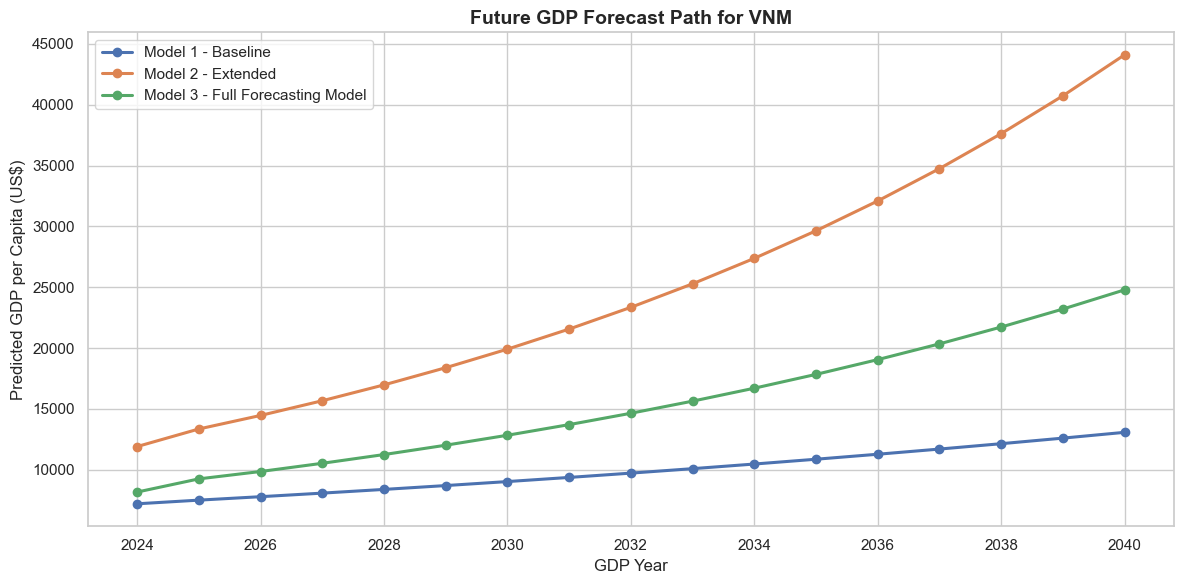

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(
    gdp_forecast_path["predicted_gdp_year"],
    gdp_forecast_path["predicted_gdp_model_1"],
    marker="o",
    linewidth=2.2,
    label="Model 1 - Baseline"
)
plt.plot(
    gdp_forecast_path["predicted_gdp_year"],
    gdp_forecast_path["predicted_gdp_model_2"],
    marker="o",
    linewidth=2.2,
    label="Model 2 - Extended"
)
plt.plot(
    gdp_forecast_path["predicted_gdp_year"],
    gdp_forecast_path["predicted_gdp_model_3"],
    marker="o",
    linewidth=2.2,
    label="Model 3 - Full Forecasting Model"
)

plt.title(f"Future GDP Forecast Path for {country_code_input}", fontsize=14, fontweight="bold")
plt.xlabel("GDP Year")
plt.ylabel("Predicted GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
# Cell 1 - Imports and global config

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
RAW_DIR = BASE_DIR / "Data" / "Raw"
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

PANEL_PATH = CLEAN_DIR / "panel_with_event_dummies_and_extra_drivers.csv"

FORECAST_BASE_YEAR = 2023
TARGET_YEAR_INPUT = 2040
COUNTRY_CODE_INPUT = "VNM"

MODEL_2_ALPHA = 0.005
MODEL_2_L1_RATIO = 0.9

AUX_FORECAST_METHODS = {
    "population_total": "LogHolt",
    "life_expectancy_years": "Naive",
    "inflation_pct_clean": "Naive",
    "unemployment_pct_clean": "Naive",
    "internet_users_pct_clean": "Holt",
}

print("Panel path:", PANEL_PATH)
print("Forecast base year:", FORECAST_BASE_YEAR)
print("Target year input:", TARGET_YEAR_INPUT)
print("Country code input:", COUNTRY_CODE_INPUT)

Panel path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Forecast base year: 2023
Target year input: 2040
Country code input: VNM


In [2]:
# Cell 2 - Resolve raw files and define IO helpers

def find_raw_file(*patterns):
    for pattern in patterns:
        matches = sorted(RAW_DIR.glob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"No file found for patterns: {patterns}")

GDP_RAW_PATH = find_raw_file("gdp.csv")
LIFE_RAW_PATH = find_raw_file("life_expectancy.csv")
POP_RAW_PATH = find_raw_file("population.csv")
INFLATION_RAW_PATH = find_raw_file("inflation.csv")
UNEMPLOYMENT_RAW_PATH = find_raw_file("unemployment.csv")
INTERNET_RAW_PATH = find_raw_file("*Internet*.csv", "*internet*.csv")

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    return df

print("GDP raw:", GDP_RAW_PATH)
print("Life raw:", LIFE_RAW_PATH)
print("Population raw:", POP_RAW_PATH)
print("Inflation raw:", INFLATION_RAW_PATH)
print("Unemployment raw:", UNEMPLOYMENT_RAW_PATH)
print("Internet raw:", INTERNET_RAW_PATH)

GDP raw: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Life raw: /Users/tonytony/Final Project/Data/Raw/life_expectancy.csv
Population raw: /Users/tonytony/Final Project/Data/Raw/population.csv
Inflation raw: /Users/tonytony/Final Project/Data/Raw/inflation.csv
Unemployment raw: /Users/tonytony/Final Project/Data/Raw/unemployment.csv
Internet raw: /Users/tonytony/Final Project/Data/Raw/individuals_using_ the_Internet.csv


In [3]:
# Cell 3 - Load cleaned panel and country info

panel_df = pd.read_csv(PANEL_PATH)

for col in ["country_name", "country_code", "wb_region"]:
    panel_df[col] = panel_df[col].astype(str).str.strip()

panel_df["year"] = pd.to_numeric(panel_df["year"], errors="coerce").astype(int)
panel_df["year_trend"] = panel_df["year"] - panel_df["year"].min()

country_info = (
    panel_df[["country_code", "country_name", "wb_region"]]
    .dropna()
    .drop_duplicates(subset=["country_code"])
    .copy()
)

valid_country_codes = set(country_info["country_code"].unique())

print("Panel shape:", panel_df.shape)
print("Countries in cleaned panel:", len(valid_country_codes))
print("Panel year range:", int(panel_df["year"].min()), "-", int(panel_df["year"].max()))

display(country_info.head())

Panel shape: (11373, 26)
Countries in cleaned panel: 214
Panel year range: 1960 - 2023


,country_code,country_name,wb_region
0,ABW,Aruba,Latin America & Caribbean
38,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan"
62,AGO,Angola,Sub-Saharan Africa
106,ALB,Albania,Europe & Central Asia
150,AND,Andorra,Europe & Central Asia


In [4]:
# Cell 4 - Convert raw WDI files to long format aligned with the cleaned panel countries

def to_long(path, value_col, country_info_df, cutoff_year=FORECAST_BASE_YEAR):
    wide = load_wdi(path)

    year_cols = [c for c in wide.columns if str(c).isdigit()]

    long_df = wide.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=value_col
    )

    long_df = long_df.rename(
        columns={
            "Country Name": "country_name_raw",
            "Country Code": "country_code"
        }
    )

    long_df["country_code"] = long_df["country_code"].astype(str).str.strip()
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    long_df[value_col] = pd.to_numeric(long_df[value_col], errors="coerce")

    long_df = long_df[long_df["country_code"].isin(country_info_df["country_code"])].copy()
    long_df = long_df.merge(country_info_df, on="country_code", how="inner")
    long_df = long_df[long_df["year"].notna()].copy()
    long_df["year"] = long_df["year"].astype(int)
    long_df = long_df[long_df["year"] <= cutoff_year].copy()

    return long_df.sort_values(["country_code", "year"]).reset_index(drop=True)

gdp_long = to_long(GDP_RAW_PATH, "gdp_per_capita_usd", country_info)
life_long = to_long(LIFE_RAW_PATH, "life_expectancy_years", country_info)
pop_long = to_long(POP_RAW_PATH, "population_total", country_info)
inflation_long = to_long(INFLATION_RAW_PATH, "inflation_pct_clean", country_info)
unemployment_long = to_long(UNEMPLOYMENT_RAW_PATH, "unemployment_pct_clean", country_info)
internet_long = to_long(INTERNET_RAW_PATH, "internet_users_pct_clean", country_info)

print("GDP long:", gdp_long.shape)
print("Life long:", life_long.shape)
print("Population long:", pop_long.shape)
print("Inflation long:", inflation_long.shape)
print("Unemployment long:", unemployment_long.shape)
print("Internet long:", internet_long.shape)

display(gdp_long.head())
display(life_long.head())
display(pop_long.head())

GDP long: (13696, 6)
Life long: (13696, 6)
Population long: (13696, 6)
Inflation long: (13696, 6)
Unemployment long: (13696, 6)
Internet long: (13696, 6)


,country_name_raw,country_code,year,gdp_per_capita_usd,country_name,wb_region
0,Aruba,ABW,1960,NaN,Aruba,Latin America & Caribbean
1,Aruba,ABW,1961,NaN,Aruba,Latin America & Caribbean
2,Aruba,ABW,1962,NaN,Aruba,Latin America & Caribbean
3,Aruba,ABW,1963,NaN,Aruba,Latin America & Caribbean
4,Aruba,ABW,1964,NaN,Aruba,Latin America & Caribbean


,country_name_raw,country_code,year,life_expectancy_years,country_name,wb_region
0,Aruba,ABW,1960,64.0490,Aruba,Latin America & Caribbean
1,Aruba,ABW,1961,64.2150,Aruba,Latin America & Caribbean
2,Aruba,ABW,1962,64.6020,Aruba,Latin America & Caribbean
3,Aruba,ABW,1963,64.9440,Aruba,Latin America & Caribbean
4,Aruba,ABW,1964,65.3030,Aruba,Latin America & Caribbean


,country_name_raw,country_code,year,population_total,country_name,wb_region
0,Aruba,ABW,1960,"54,922.0000",Aruba,Latin America & Caribbean
1,Aruba,ABW,1961,"55,578.0000",Aruba,Latin America & Caribbean
2,Aruba,ABW,1962,"56,320.0000",Aruba,Latin America & Caribbean
3,Aruba,ABW,1963,"57,002.0000",Aruba,Latin America & Caribbean
4,Aruba,ABW,1964,"57,619.0000",Aruba,Latin America & Caribbean


In [5]:
# Cell 5 - Train final main models on all available historical rows

FORMULA_MODEL_1 = """
target_log_gdp_next_year ~ log_gdp_per_capita + log_population_total + life_expectancy_years
"""

FORMULA_MODEL_3 = """
target_log_gdp_next_year ~ log_gdp_per_capita + log_population_total + life_expectancy_years
+ inflation_pct_clean + unemployment_pct_clean + internet_users_pct_clean
+ asian_financial_crisis_9798 + global_financial_crisis_0809
+ C(wb_region) + year_trend
"""

MODEL_2_FEATURES = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
]

model_1_cols = [
    "target_log_gdp_next_year",
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
]
model_2_cols = ["target_log_gdp_next_year"] + MODEL_2_FEATURES
model_3_cols = [
    "target_log_gdp_next_year",
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "wb_region",
    "year_trend",
]

model_1_df = panel_df[model_1_cols].dropna().copy()
model_2_df = panel_df[model_2_cols].dropna().copy()
model_3_df = panel_df[model_3_cols].dropna().copy()

model_1_fit = smf.ols(FORMULA_MODEL_1, data=model_1_df).fit()

model_2_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "elastic_net",
            ElasticNet(
                alpha=MODEL_2_ALPHA,
                l1_ratio=MODEL_2_L1_RATIO,
                max_iter=200000
            )
        ),
    ]
)
model_2_pipe.fit(model_2_df[MODEL_2_FEATURES], model_2_df["target_log_gdp_next_year"])

model_3_fit = smf.ols(FORMULA_MODEL_3, data=model_3_df).fit()

YEAR_BASE = int(panel_df["year"].min())

print("Model 1 training rows:", model_1_df.shape[0])
print("Model 2 training rows:", model_2_df.shape[0])
print("Model 3 training rows:", model_3_df.shape[0])
print("Year base for year_trend:", YEAR_BASE)

summary_algorithms = pd.DataFrame(
    {
        "Model": ["Model 1", "Model 2", "Model 3"],
        "Chosen algorithm": ["OLS", "Elastic Net", "OLS"],
        "Reason": [
            "Best by final benchmark for Specification 1",
            "Best by final benchmark for Specification 2",
            "Best final explanatory model and best overall rank score"
        ]
    }
)
display(summary_algorithms)

Model 1 training rows: 11159
Model 2 training rows: 4722
Model 3 training rows: 4722
Year base for year_trend: 1960


,Model,Chosen algorithm,Reason
0,Model 1,OLS,Best by final benchmark for Specification 1
1,Model 2,Elastic Net,Best by final benchmark for Specification 2
2,Model 3,OLS,Best final explanatory model and best overall ...


In [6]:
# Cell 6 - Forecast helpers for future inputs

def safe_clip(values, lower=None, upper=None):
    lower_bound = -np.inf if lower is None else lower
    upper_bound = np.inf if upper is None else upper
    return np.clip(np.asarray(values, dtype=float), lower_bound, upper_bound)

def get_country_series(long_df, country_code, value_col, cutoff_year=FORECAST_BASE_YEAR):
    out = (
        long_df.loc[
            (long_df["country_code"] == country_code) & (long_df["year"] <= cutoff_year),
            ["year", value_col]
        ]
        .dropna()
        .groupby("year", as_index=False)[value_col]
        .mean()
        .sort_values("year")
        .reset_index(drop=True)
    )
    return out

def get_country_or_region_fallback(panel_source_df, country_code, value_col):
    country_slice = (
        panel_source_df.loc[
            (panel_source_df["country_code"] == country_code) & panel_source_df[value_col].notna(),
            ["year", value_col]
        ]
        .sort_values("year")
    )
    if not country_slice.empty:
        return float(country_slice.iloc[-1][value_col])

    region_name = country_info.loc[country_info["country_code"] == country_code, "wb_region"].iloc[0]

    region_slice = (
        panel_source_df.loc[
            (panel_source_df["wb_region"] == region_name) & panel_source_df[value_col].notna(),
            ["year", value_col]
        ]
        .sort_values("year")
    )
    if not region_slice.empty:
        return float(region_slice.iloc[-1][value_col])

    global_slice = panel_source_df[value_col].dropna()
    if not global_slice.empty:
        return float(global_slice.median())

    raise ValueError(f"No fallback value available for {value_col} and country {country_code}")

def forecast_value_map(
    long_df,
    country_code,
    value_col,
    target_year,
    method,
    cutoff_year=FORECAST_BASE_YEAR,
    lower=None,
    upper=None,
    fallback_value=None,
):
    series_df = get_country_series(long_df, country_code, value_col, cutoff_year=cutoff_year)

    if series_df.empty:
        if fallback_value is None:
            raise ValueError(f"No historical series for {country_code} - {value_col}")
        return {year: float(fallback_value) for year in range(cutoff_year, target_year + 1)}

    actual_map = dict(zip(series_df["year"], series_df[value_col]))
    latest_actual_year = int(series_df["year"].max())

    if target_year <= latest_actual_year:
        return actual_map

    y = series_df.set_index("year")[value_col].astype(float).sort_index()
    future_years = list(range(latest_actual_year + 1, target_year + 1))
    horizon = len(future_years)

    def naive_forecast():
        return np.repeat(float(y.iloc[-1]), horizon)

    try:
        if (len(y) < 3) or (y.nunique() <= 1):
            future_values = naive_forecast()

        elif method == "Naive":
            future_values = naive_forecast()

        elif method == "Holt":
            fit = ExponentialSmoothing(
                y,
                trend="add",
                seasonal=None,
                initialization_method="estimated"
            ).fit(optimized=True)
            future_values = fit.forecast(horizon).values

        elif method == "LogHolt":
            if (y <= 0).any():
                future_values = naive_forecast()
            else:
                fit = ExponentialSmoothing(
                    np.log(y),
                    trend="add",
                    seasonal=None,
                    initialization_method="estimated"
                ).fit(optimized=True)
                future_values = np.exp(fit.forecast(horizon).values)

        else:
            future_values = naive_forecast()

    except Exception:
        future_values = naive_forecast()

    future_values = safe_clip(future_values, lower=lower, upper=upper)

    out_map = actual_map.copy()
    for year, value in zip(future_years, future_values):
        out_map[int(year)] = float(value)

    return out_map

assumption_table = pd.DataFrame(
    {
        "Future input": [
            "Population",
            "Life expectancy",
            "Inflation",
            "Unemployment",
            "Internet users"
        ],
        "Method used": [
            "LogHolt",
            "Naive",
            "Naive",
            "Naive",
            "Holt (bounded to 0-100)"
        ],
    }
)

display(assumption_table)

,Future input,Method used
0,Population,LogHolt
1,Life expectancy,Naive
2,Inflation,Naive
3,Unemployment,Naive
4,Internet users,Holt (bounded to 0-100)


In [7]:
# Cell 7 - Main-model recursive future GDP forecast

def build_future_feature_row(
    feature_year,
    country_name,
    country_code,
    wb_region,
    gdp_current,
    population_value,
    life_value,
    inflation_value,
    unemployment_value,
    internet_value,
):
    row = {
        "country_name": country_name,
        "country_code": country_code,
        "wb_region": wb_region,
        "year": int(feature_year),
        "year_trend": int(feature_year - YEAR_BASE),
        "gdp_per_capita_usd": float(gdp_current),
        "log_gdp_per_capita": float(np.log(max(gdp_current, 1e-9))),
        "population_total": float(population_value),
        "log_population_total": float(np.log(max(population_value, 1e-9))),
        "life_expectancy_years": float(life_value),
        "inflation_pct_clean": float(inflation_value),
        "unemployment_pct_clean": float(unemployment_value),
        "internet_users_pct_clean": float(internet_value),
        "asian_financial_crisis_9798": int(feature_year in [1997, 1998]),
        "global_financial_crisis_0809": int(feature_year in [2008, 2009]),
    }
    return row

def predict_next_gdp_from_row(row_dict, model_name):
    row_df = pd.DataFrame([row_dict])

    if model_name == "Model 1":
        pred_log = float(model_1_fit.predict(row_df).iloc[0])

    elif model_name == "Model 2":
        pred_log = float(
            model_2_pipe.predict(row_df[MODEL_2_FEATURES])[0]
        )

    elif model_name == "Model 3":
        pred_log = float(model_3_fit.predict(row_df).iloc[0])

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return float(np.exp(pred_log))

def recursive_main_model_future_forecast(country_code, target_gdp_year, model_name):
    country_code = str(country_code).strip().upper()

    country_meta = country_info.loc[country_info["country_code"] == country_code]
    if country_meta.empty:
        raise ValueError(f"Country code {country_code} is not available in the cleaned panel.")

    country_name = country_meta.iloc[0]["country_name"]
    wb_region = country_meta.iloc[0]["wb_region"]

    if target_gdp_year <= FORECAST_BASE_YEAR:
        raise ValueError(
            f"Target GDP year must be greater than {FORECAST_BASE_YEAR} for true future forecasting."
        )

    target_feature_year = target_gdp_year - 1

    gdp_hist_df = get_country_series(gdp_long, country_code, "gdp_per_capita_usd", cutoff_year=FORECAST_BASE_YEAR)
    if gdp_hist_df.empty:
        raise ValueError(f"No GDP history found for {country_code}.")

    gdp_path = dict(zip(gdp_hist_df["year"], gdp_hist_df["gdp_per_capita_usd"]))
    latest_actual_gdp_year = int(gdp_hist_df["year"].max())

    pop_fallback = get_country_or_region_fallback(panel_df, country_code, "population_total")
    life_fallback = get_country_or_region_fallback(panel_df, country_code, "life_expectancy_years")
    inf_fallback = get_country_or_region_fallback(panel_df, country_code, "inflation_pct_clean")
    unemp_fallback = get_country_or_region_fallback(panel_df, country_code, "unemployment_pct_clean")
    internet_fallback = get_country_or_region_fallback(panel_df, country_code, "internet_users_pct_clean")

    pop_map = forecast_value_map(
        pop_long,
        country_code,
        "population_total",
        target_feature_year,
        method=AUX_FORECAST_METHODS["population_total"],
        cutoff_year=FORECAST_BASE_YEAR,
        lower=1.0,
        fallback_value=pop_fallback,
    )
    life_map = forecast_value_map(
        life_long,
        country_code,
        "life_expectancy_years",
        target_feature_year,
        method=AUX_FORECAST_METHODS["life_expectancy_years"],
        cutoff_year=FORECAST_BASE_YEAR,
        lower=0.0,
        upper=100.0,
        fallback_value=life_fallback,
    )
    inflation_map = forecast_value_map(
        inflation_long,
        country_code,
        "inflation_pct_clean",
        target_feature_year,
        method=AUX_FORECAST_METHODS["inflation_pct_clean"],
        cutoff_year=FORECAST_BASE_YEAR,
        fallback_value=inf_fallback,
    )
    unemployment_map = forecast_value_map(
        unemployment_long,
        country_code,
        "unemployment_pct_clean",
        target_feature_year,
        method=AUX_FORECAST_METHODS["unemployment_pct_clean"],
        cutoff_year=FORECAST_BASE_YEAR,
        lower=0.0,
        upper=100.0,
        fallback_value=unemp_fallback,
    )
    internet_map = forecast_value_map(
        internet_long,
        country_code,
        "internet_users_pct_clean",
        target_feature_year,
        method=AUX_FORECAST_METHODS["internet_users_pct_clean"],
        cutoff_year=FORECAST_BASE_YEAR,
        lower=0.0,
        upper=100.0,
        fallback_value=internet_fallback,
    )

    output_rows = []

    for feature_year in range(latest_actual_gdp_year, target_feature_year + 1):
        current_gdp = float(gdp_path[feature_year])

        row = build_future_feature_row(
            feature_year=feature_year,
            country_name=country_name,
            country_code=country_code,
            wb_region=wb_region,
            gdp_current=current_gdp,
            population_value=pop_map[feature_year],
            life_value=life_map[feature_year],
            inflation_value=inflation_map[feature_year],
            unemployment_value=unemployment_map[feature_year],
            internet_value=internet_map[feature_year],
        )

        predicted_next_gdp = predict_next_gdp_from_row(row, model_name=model_name)
        target_year = feature_year + 1
        gdp_path[target_year] = predicted_next_gdp

        row_out = row.copy()
        row_out["model_name"] = model_name
        row_out["target_year"] = int(target_year)
        row_out["predicted_gdp_next_year"] = float(predicted_next_gdp)
        output_rows.append(row_out)

    forecast_df = pd.DataFrame(output_rows)

    return {
        "country_code": country_code,
        "country_name": country_name,
        "wb_region": wb_region,
        "latest_actual_gdp_year": latest_actual_gdp_year,
        "historical_gdp_df": gdp_hist_df.copy(),
        "forecast_df": forecast_df.copy(),
        "gdp_path": gdp_path.copy(),
    }

In [8]:
# Cell 8 - Run future forecast for Model 1, Model 2, Model 3

result_m1 = recursive_main_model_future_forecast(
    country_code=COUNTRY_CODE_INPUT,
    target_gdp_year=TARGET_YEAR_INPUT,
    model_name="Model 1"
)

result_m2 = recursive_main_model_future_forecast(
    country_code=COUNTRY_CODE_INPUT,
    target_gdp_year=TARGET_YEAR_INPUT,
    model_name="Model 2"
)

result_m3 = recursive_main_model_future_forecast(
    country_code=COUNTRY_CODE_INPUT,
    target_gdp_year=TARGET_YEAR_INPUT,
    model_name="Model 3"
)

forecast_m1_df = result_m1["forecast_df"].copy()
forecast_m2_df = result_m2["forecast_df"].copy()
forecast_m3_df = result_m3["forecast_df"].copy()

display(forecast_m1_df.head())
display(forecast_m2_df.head())
display(forecast_m3_df.head())

latest_actual_gdp = float(result_m1["historical_gdp_df"].iloc[-1]["gdp_per_capita_usd"])

future_summary = pd.DataFrame(
    [
        {
            "Model": "Model 1 - OLS",
            "Forecast target year": TARGET_YEAR_INPUT,
            "Forecast GDP per capita": forecast_m1_df.iloc[-1]["predicted_gdp_next_year"],
            "Absolute change vs 2023": forecast_m1_df.iloc[-1]["predicted_gdp_next_year"] - latest_actual_gdp,
            "Growth vs 2023 (%)": ((forecast_m1_df.iloc[-1]["predicted_gdp_next_year"] / latest_actual_gdp) - 1) * 100,
        },
        {
            "Model": "Model 2 - Elastic Net",
            "Forecast target year": TARGET_YEAR_INPUT,
            "Forecast GDP per capita": forecast_m2_df.iloc[-1]["predicted_gdp_next_year"],
            "Absolute change vs 2023": forecast_m2_df.iloc[-1]["predicted_gdp_next_year"] - latest_actual_gdp,
            "Growth vs 2023 (%)": ((forecast_m2_df.iloc[-1]["predicted_gdp_next_year"] / latest_actual_gdp) - 1) * 100,
        },
        {
            "Model": "Model 3 - OLS",
            "Forecast target year": TARGET_YEAR_INPUT,
            "Forecast GDP per capita": forecast_m3_df.iloc[-1]["predicted_gdp_next_year"],
            "Absolute change vs 2023": forecast_m3_df.iloc[-1]["predicted_gdp_next_year"] - latest_actual_gdp,
            "Growth vs 2023 (%)": ((forecast_m3_df.iloc[-1]["predicted_gdp_next_year"] / latest_actual_gdp) - 1) * 100,
        },
    ]
)

display(future_summary.round(2))

,country_name,country_code,wb_region,year,year_trend,gdp_per_capita_usd,log_gdp_per_capita,population_total,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,model_name,target_year,predicted_gdp_next_year
0,Viet Nam,VNM,East Asia & Pacific,2023,63,"4,323.3503",8.3718,"100,352,192.0000",18.4242,74.5880,3.2529,1.6450,78.0800,0,0,Model 1,2024,"4,563.5088"
1,Viet Nam,VNM,East Asia & Pacific,2024,64,"4,563.5088",8.4258,"101,028,253.0686",18.4309,74.5880,3.2529,1.6450,80.9543,0,0,Model 1,2025,"4,811.2525"
2,Viet Nam,VNM,East Asia & Pacific,2025,65,"4,811.2525",8.4787,"101,708,868.6810",18.4376,74.5880,3.2529,1.6450,83.8287,0,0,Model 1,2026,"5,066.5169"
3,Viet Nam,VNM,East Asia & Pacific,2026,66,"5,066.5169",8.5304,"102,394,069.5217",18.4443,74.5880,3.2529,1.6450,86.7030,0,0,Model 1,2027,"5,329.2238"
4,Viet Nam,VNM,East Asia & Pacific,2027,67,"5,329.2238",8.5810,"103,083,886.4809",18.4511,74.5880,3.2529,1.6450,89.5773,0,0,Model 1,2028,"5,599.2821"


,country_name,country_code,wb_region,year,year_trend,gdp_per_capita_usd,log_gdp_per_capita,population_total,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,model_name,target_year,predicted_gdp_next_year
0,Viet Nam,VNM,East Asia & Pacific,2023,63,"4,323.3503",8.3718,"100,352,192.0000",18.4242,74.5880,3.2529,1.6450,78.0800,0,0,Model 2,2024,"4,573.8332"
1,Viet Nam,VNM,East Asia & Pacific,2024,64,"4,573.8332",8.4281,"101,028,253.0686",18.4309,74.5880,3.2529,1.6450,80.9543,0,0,Model 2,2025,"4,833.0269"
2,Viet Nam,VNM,East Asia & Pacific,2025,65,"4,833.0269",8.4832,"101,708,868.6810",18.4376,74.5880,3.2529,1.6450,83.8287,0,0,Model 2,2026,"5,100.9162"
3,Viet Nam,VNM,East Asia & Pacific,2026,66,"5,100.9162",8.5372,"102,394,069.5217",18.4443,74.5880,3.2529,1.6450,86.7030,0,0,Model 2,2027,"5,377.4715"
4,Viet Nam,VNM,East Asia & Pacific,2027,67,"5,377.4715",8.5900,"103,083,886.4809",18.4511,74.5880,3.2529,1.6450,89.5773,0,0,Model 2,2028,"5,662.6487"


,country_name,country_code,wb_region,year,year_trend,gdp_per_capita_usd,log_gdp_per_capita,population_total,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,model_name,target_year,predicted_gdp_next_year
0,Viet Nam,VNM,East Asia & Pacific,2023,63,"4,323.3503",8.3718,"100,352,192.0000",18.4242,74.5880,3.2529,1.6450,78.0800,0,0,Model 3,2024,"4,491.9342"
1,Viet Nam,VNM,East Asia & Pacific,2024,64,"4,491.9342",8.4100,"101,028,253.0686",18.4309,74.5880,3.2529,1.6450,80.9543,0,0,Model 3,2025,"4,658.1414"
2,Viet Nam,VNM,East Asia & Pacific,2025,65,"4,658.1414",8.4464,"101,708,868.6810",18.4376,74.5880,3.2529,1.6450,83.8287,0,0,Model 3,2026,"4,821.3853"
3,Viet Nam,VNM,East Asia & Pacific,2026,66,"4,821.3853",8.4808,"102,394,069.5217",18.4443,74.5880,3.2529,1.6450,86.7030,0,0,Model 3,2027,"4,981.0883"
4,Viet Nam,VNM,East Asia & Pacific,2027,67,"4,981.0883",8.5134,"103,083,886.4809",18.4511,74.5880,3.2529,1.6450,89.5773,0,0,Model 3,2028,"5,136.6857"


,Model,Forecast target year,Forecast GDP per capita,Absolute change vs 2023,Growth vs 2023 (%)
0,Model 1 - OLS,2040,"9,364.0800","5,040.7300",116.5900
1,Model 2 - Elastic Net,2040,"9,722.8900","5,399.5300",124.8900
2,Model 3 - OLS,2040,"6,579.9700","2,256.6200",52.2000


In [9]:
# Cell 9 - Build compare table for the full future path

hist_df = result_m1["historical_gdp_df"].copy()
hist_df = hist_df.rename(columns={"gdp_per_capita_usd": "actual_gdp_per_capita"})

compare_future_df = pd.DataFrame(
    {
        "year": forecast_m1_df["target_year"].astype(int),
        "Model 1 - OLS": forecast_m1_df["predicted_gdp_next_year"].values,
        "Model 2 - Elastic Net": forecast_m2_df["predicted_gdp_next_year"].values,
        "Model 3 - OLS": forecast_m3_df["predicted_gdp_next_year"].values,
    }
)

display(compare_future_df.head())
display(compare_future_df.tail())

,year,Model 1 - OLS,Model 2 - Elastic Net,Model 3 - OLS
0,2024,"4,563.5088","4,573.8332","4,491.9342"
1,2025,"4,811.2525","4,833.0269","4,658.1414"
2,2026,"5,066.5169","5,100.9162","4,821.3853"
3,2027,"5,329.2238","5,377.4715","4,981.0883"
4,2028,"5,599.2821","5,662.6487","5,136.6857"


,year,Model 1 - OLS,Model 2 - Elastic Net,Model 3 - OLS
12,2036,"8,009.4308","8,244.6382","6,193.2453"
13,2037,"8,339.5822","8,603.1969","6,299.8087"
14,2038,"8,675.5449","8,969.2124","6,399.9310"
15,2039,"9,017.1135","9,342.5050","6,493.3857"
16,2040,"9,364.0757","9,722.8851","6,579.9725"


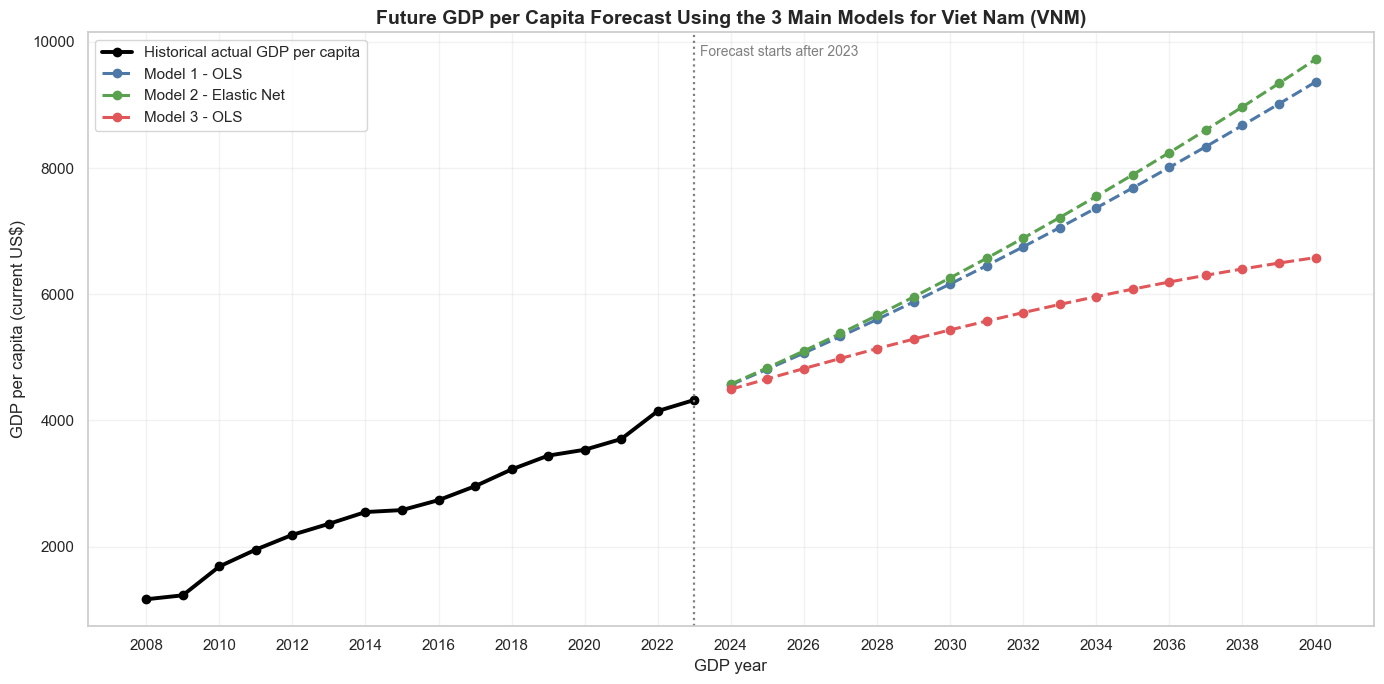

In [10]:
# Cell 10 - Plot historical actual + future main-model forecasts

plot_start_year = max(2008, int(hist_df["year"].min()))

hist_plot_df = hist_df[hist_df["year"] >= plot_start_year].copy()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    hist_plot_df["year"],
    hist_plot_df["actual_gdp_per_capita"],
    color="black",
    linewidth=2.8,
    marker="o",
    label="Historical actual GDP per capita"
)

ax.plot(
    compare_future_df["year"],
    compare_future_df["Model 1 - OLS"],
    linestyle="--",
    linewidth=2.2,
    marker="o",
    color="#4E79A7",
    label="Model 1 - OLS"
)

ax.plot(
    compare_future_df["year"],
    compare_future_df["Model 2 - Elastic Net"],
    linestyle="--",
    linewidth=2.2,
    marker="o",
    color="#59A14F",
    label="Model 2 - Elastic Net"
)

ax.plot(
    compare_future_df["year"],
    compare_future_df["Model 3 - OLS"],
    linestyle="--",
    linewidth=2.2,
    marker="o",
    color="#E15759",
    label="Model 3 - OLS"
)

ax.axvline(
    x=FORECAST_BASE_YEAR,
    color="gray",
    linestyle=":",
    linewidth=1.6
)

ax.text(
    FORECAST_BASE_YEAR + 0.15,
    ax.get_ylim()[1] * 0.98,
    "Forecast starts after 2023",
    fontsize=10,
    color="gray",
    va="top"
)

xticks = list(range(plot_start_year, TARGET_YEAR_INPUT + 1, 2))
if TARGET_YEAR_INPUT not in xticks:
    xticks.append(TARGET_YEAR_INPUT)
xticks = sorted(set(xticks))

ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], rotation=0)

ax.set_title(
    f"Future GDP per Capita Forecast Using the 3 Main Models for {result_m1['country_name']} ({COUNTRY_CODE_INPUT})",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("GDP year")
ax.set_ylabel("GDP per capita (current US$)")
ax.legend(frameon=True, loc="upper left")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

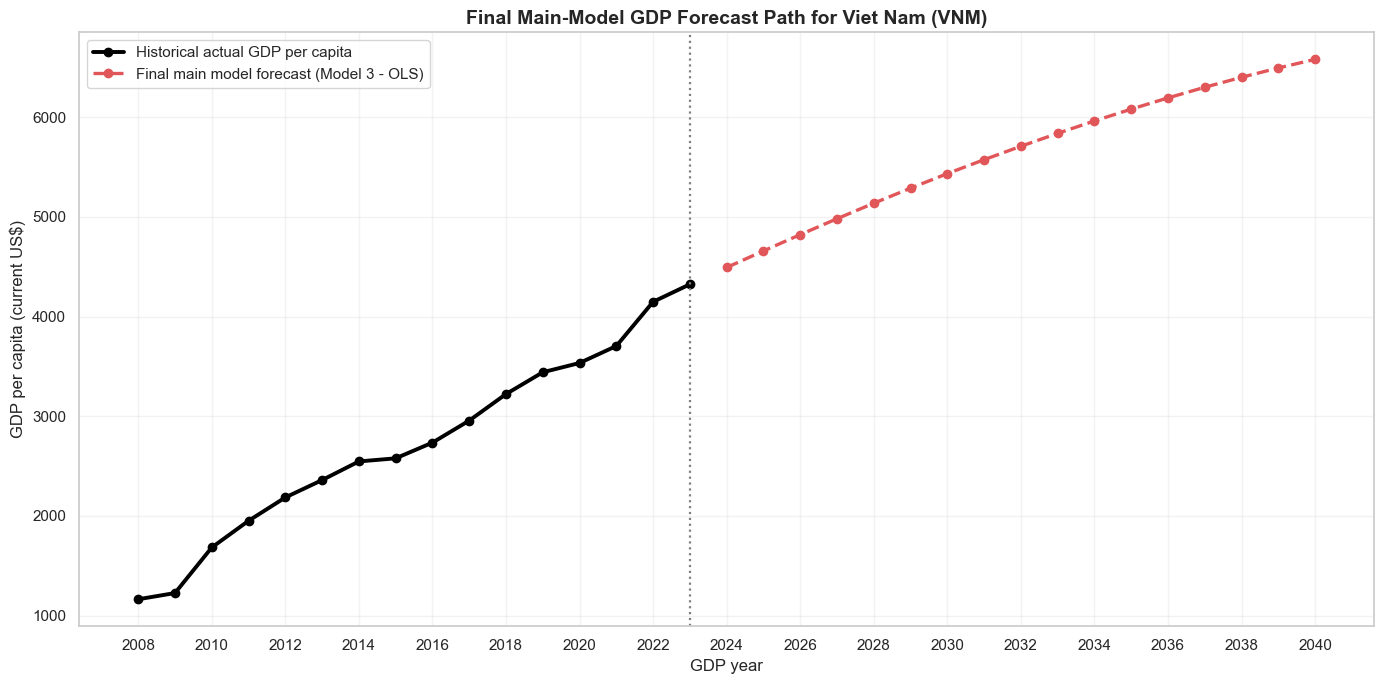

In [11]:
# Cell 11 - Optional single-final-model chart (recommended final path = Model 3 - OLS)

final_model_plot_df = forecast_m3_df.copy()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    hist_plot_df["year"],
    hist_plot_df["actual_gdp_per_capita"],
    color="black",
    linewidth=2.8,
    marker="o",
    label="Historical actual GDP per capita"
)

ax.plot(
    final_model_plot_df["target_year"],
    final_model_plot_df["predicted_gdp_next_year"],
    linestyle="--",
    linewidth=2.4,
    marker="o",
    color="#E15759",
    label="Final main model forecast (Model 3 - OLS)"
)

ax.axvline(
    x=FORECAST_BASE_YEAR,
    color="gray",
    linestyle=":",
    linewidth=1.6
)

xticks = list(range(plot_start_year, TARGET_YEAR_INPUT + 1, 2))
if TARGET_YEAR_INPUT not in xticks:
    xticks.append(TARGET_YEAR_INPUT)
xticks = sorted(set(xticks))

ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks])

ax.set_title(
    f"Final Main-Model GDP Forecast Path for {result_m3['country_name']} ({COUNTRY_CODE_INPUT})",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("GDP year")
ax.set_ylabel("GDP per capita (current US$)")
ax.legend(frameon=True, loc="upper left")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [12]:
# Cell 12 - Export forecast outputs

compare_save_path = CLEAN_DIR / f"main_models_future_forecast_compare_{COUNTRY_CODE_INPUT}_{TARGET_YEAR_INPUT}.csv"
summary_save_path = CLEAN_DIR / f"main_models_future_forecast_summary_{COUNTRY_CODE_INPUT}_{TARGET_YEAR_INPUT}.csv"
detailed_save_path = CLEAN_DIR / f"main_models_future_forecast_detailed_{COUNTRY_CODE_INPUT}_{TARGET_YEAR_INPUT}.csv"

compare_future_df.to_csv(compare_save_path, index=False)
future_summary.to_csv(summary_save_path, index=False)

detailed_all = pd.concat(
    [
        forecast_m1_df.assign(compare_model="Model 1 - OLS"),
        forecast_m2_df.assign(compare_model="Model 2 - Elastic Net"),
        forecast_m3_df.assign(compare_model="Model 3 - OLS"),
    ],
    ignore_index=True
)
detailed_all.to_csv(detailed_save_path, index=False)

print("Saved compare path:", compare_save_path)
print("Saved summary path:", summary_save_path)
print("Saved detailed path:", detailed_save_path)

Saved compare path: /Users/tonytony/Final Project/Data/Cleaned/main_models_future_forecast_compare_VNM_2040.csv
Saved summary path: /Users/tonytony/Final Project/Data/Cleaned/main_models_future_forecast_summary_VNM_2040.csv
Saved detailed path: /Users/tonytony/Final Project/Data/Cleaned/main_models_future_forecast_detailed_VNM_2040.csv


In [13]:
# Cell 13 - Quick final answer for the selected country and target year

final_answer_df = future_summary.copy()
final_answer_df["Forecast GDP per capita"] = final_answer_df["Forecast GDP per capita"].round(2)
final_answer_df["Absolute change vs 2023"] = final_answer_df["Absolute change vs 2023"].round(2)
final_answer_df["Growth vs 2023 (%)"] = final_answer_df["Growth vs 2023 (%)"].round(2)

display(final_answer_df)

print("Recommended final reporting model: Model 3 - OLS")
print("Best pure predictive benchmark by RMSE: Model 2 - Elastic Net")

,Model,Forecast target year,Forecast GDP per capita,Absolute change vs 2023,Growth vs 2023 (%)
0,Model 1 - OLS,2040,"9,364.0800","5,040.7300",116.5900
1,Model 2 - Elastic Net,2040,"9,722.8900","5,399.5300",124.8900
2,Model 3 - OLS,2040,"6,579.9700","2,256.6200",52.2000


Recommended final reporting model: Model 3 - OLS
Best pure predictive benchmark by RMSE: Model 2 - Elastic Net
